Piriyadharshini N
24BAD086
EXP 6



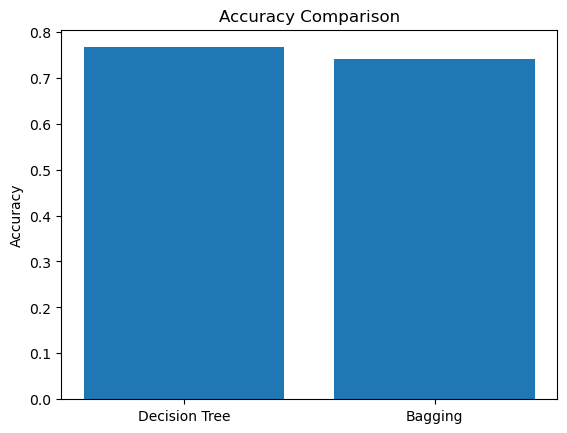

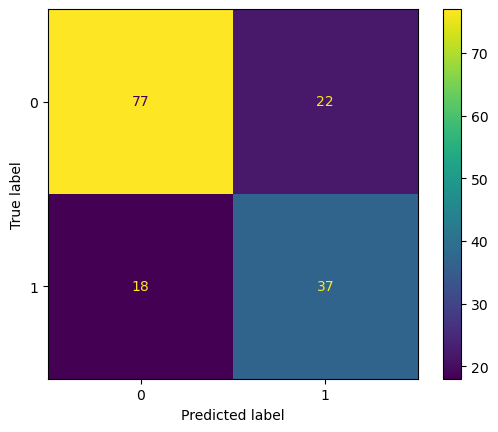

In [12]:
print("Piriyadharshini N\n24BAD086\nEXP 6\n")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

data=pd.read_csv("diabetes.csv")

X=data.drop("Outcome",axis=1)
y=data["Outcome"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)
pred_dt=dt.predict(X_test)
acc_dt=accuracy_score(y_test,pred_dt)

bag=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42)
bag.fit(X_train,y_train)
pred_bag=bag.predict(X_test)
acc_bag=accuracy_score(y_test,pred_bag)

plt.bar(["Decision Tree","Bagging"],[acc_dt,acc_bag])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

cm=confusion_matrix(y_test,pred_bag)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Piriyadharshini N
24BAD086
EXP 6

AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


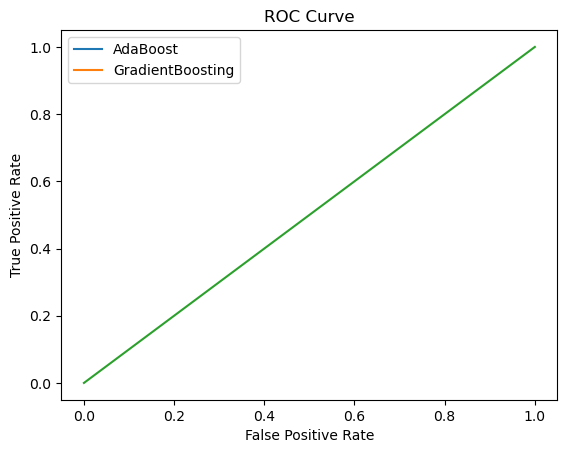

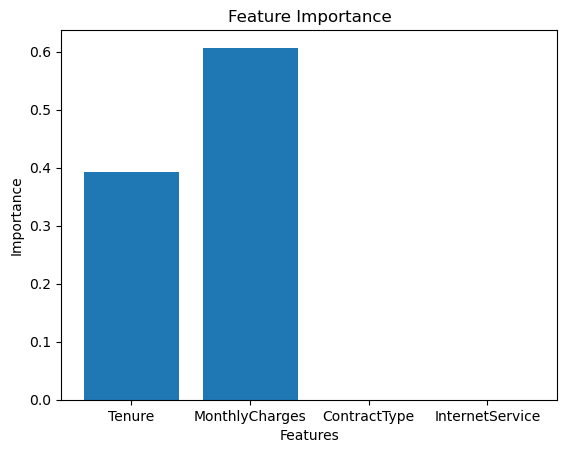

In [13]:
print("Piriyadharshini N\n24BAD086\nEXP 6\n")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score

data = pd.read_csv("churn_boosting.csv")

le = LabelEncoder()

data["ContractType"] = le.fit_transform(data["ContractType"])
data["InternetService"] = le.fit_transform(data["InternetService"])
data["Churn"] = le.fit_transform(data["Churn"])

X = data[["Tenure", "MonthlyCharges", "ContractType", "InternetService"]]
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
pred_ada = ada.predict(X_test)
prob_ada = ada.predict_proba(X_test)[:,1]

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:,1]

acc_ada = accuracy_score(y_test, pred_ada)
acc_gb = accuracy_score(y_test, pred_gb)

print("AdaBoost Accuracy:", acc_ada)
print("Gradient Boosting Accuracy:", acc_gb)

fpr1, tpr1, _ = roc_curve(y_test, prob_ada)
fpr2, tpr2, _ = roc_curve(y_test, prob_gb)

roc_auc1 = auc(fpr1, tpr1)
roc_auc2 = auc(fpr2, tpr2)

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="GradientBoosting")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.bar(X.columns, gb.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

Piriyadharshini N
24BAD086
EXP 6



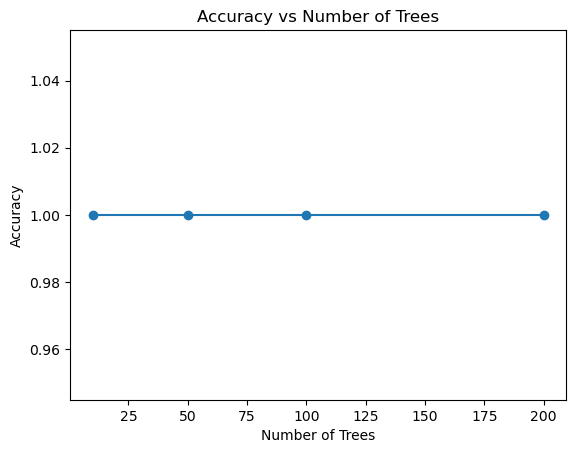

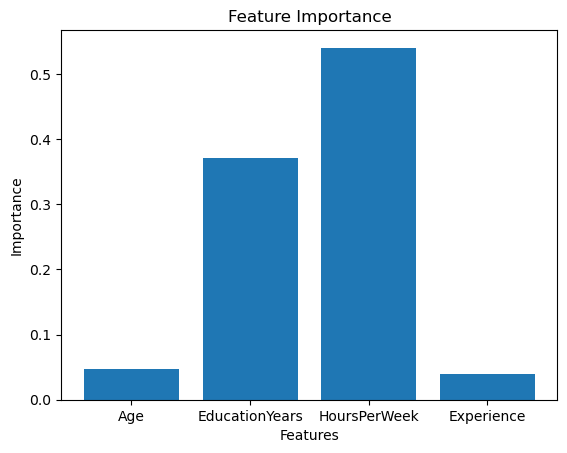

In [14]:
print("Piriyadharshini N\n24BAD086\nEXP 6\n")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv("income_random_forest.csv")

data = data.dropna()

X = data[["Age","EducationYears","HoursPerWeek","Experience"]]
y = data["Income"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

trees = [10,50,100,200]
acc = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t,random_state=42)
    rf.fit(X_train,y_train)
    pred = rf.predict(X_test)
    acc.append(accuracy_score(y_test,pred))

plt.plot(trees,acc,marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

importance = rf.feature_importances_

plt.bar(X.columns,importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

Piriyadharshini N
24BAD086
EXP 6



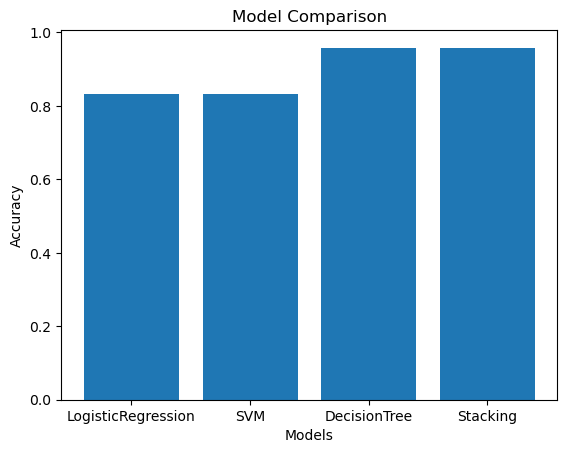

In [15]:
print("Piriyadharshini N\n24BAD086\nEXP 6\n")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv("heart_stacking.csv")

X = data[["Age","Cholesterol","MaxHeartRate","RestingBP"]]
y = data["HeartDisease"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

lr.fit(X_train,y_train)
svm.fit(X_train,y_train)
dt.fit(X_train,y_train)

pred_lr = lr.predict(X_test)
pred_svm = svm.predict(X_test)
pred_dt = dt.predict(X_test)

acc_lr = accuracy_score(y_test,pred_lr)
acc_svm = accuracy_score(y_test,pred_svm)
acc_dt = accuracy_score(y_test,pred_dt)

estimators = [("lr",lr),("svm",svm),("dt",dt)]

stack = StackingClassifier(estimators=estimators,final_estimator=LogisticRegression())
stack.fit(X_train,y_train)

pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test,pred_stack)

models = ["LogisticRegression","SVM","DecisionTree","Stacking"]
scores = [acc_lr,acc_svm,acc_dt,acc_stack]

plt.bar(models,scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

Piriyadharshini N
24BAD086
EXP 6



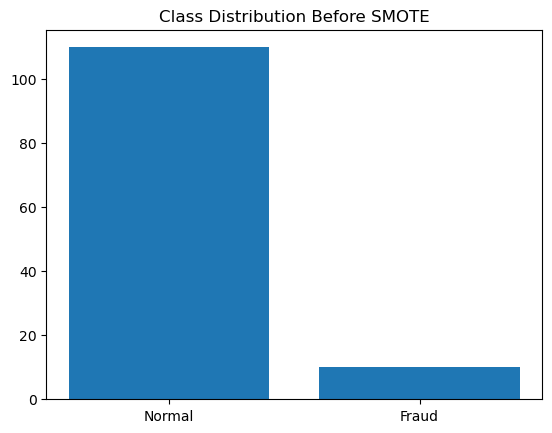

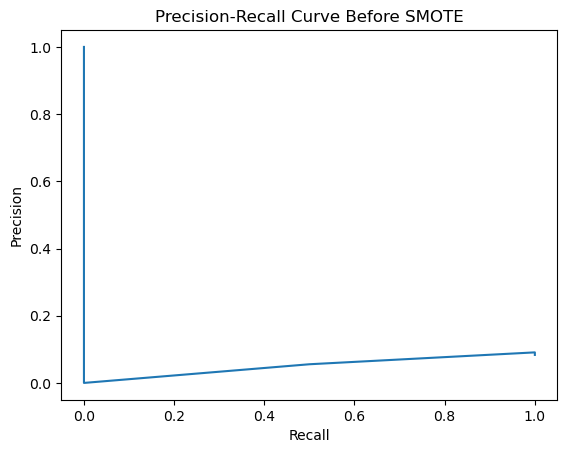

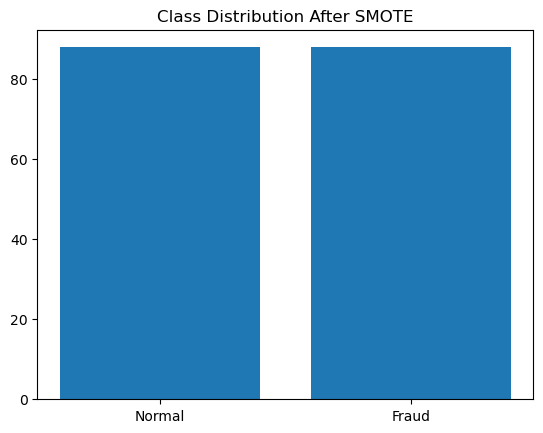

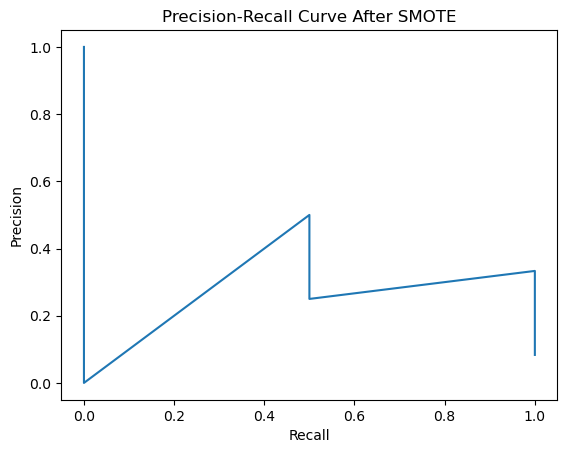

In [16]:
print("Piriyadharshini N\n24BAD086\nEXP 6\n")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE

data = pd.read_csv("fraud_smote.csv")

X = data.drop("Fraud", axis=1)
y = data["Fraud"]

plt.bar(["Normal","Fraud"], y.value_counts())
plt.title("Class Distribution Before SMOTE")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, pred)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Before SMOTE")
plt.show()

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

plt.bar(["Normal","Fraud"], pd.Series(y_res).value_counts())
plt.title("Class Distribution After SMOTE")
plt.show()

model2 = RandomForestClassifier(random_state=42)
model2.fit(X_res, y_res)

pred2 = model2.predict_proba(X_test)[:,1]

precision2, recall2, _ = precision_recall_curve(y_test, pred2)

plt.plot(recall2, precision2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve After SMOTE")
plt.show()